# Phase 2 validation — pandapower replica vs ETAP reference

`src/network/grid_model.py` rebuilds the ETAP project `electrolyzer-demo` (ETAP 20.6.0, study case `LF`, Newton-Raphson solver) from the parameters recorded in [`data/etap_parameters.md`](../data/etap_parameters.md). This notebook runs the three operating points of section 3 and compares every result against the ETAP targets of section 4.

| Case | PVA1 | ELY | Meaning |
|---|---|---|---|
| **SUNNY** | 0.5342 MW | in service (800 kW) | daytime, full sun, electrolyzer at full load |
| **NIGHT** | 0 | in service (800 kW) | no sun; grid supplies the whole load |
| **PV_EXPORT** | 0.5342 MW | out of service | surplus PV exported — grid P must go **negative** |

**Tolerances (hard gate):** bus voltage within ±0.01 pu · transformer loading within 2 percentage points · power flows and losses within 2 % of the ETAP value · PV_EXPORT grid P negative (grid absorbing ≈ 0.533 MW).

If a check misses tolerance it is reported as **FAIL** — model parameters are never tweaked to force a match.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import pandas as pd

from src.network.grid_model import build_network, run_case

# Operating points - data/etap_parameters.md section 3
CASES = {
    'SUNNY':     dict(pv_mw=0.5342, ely_in_service=True),
    'NIGHT':     dict(pv_mw=0.0,    ely_in_service=True),
    'PV_EXPORT': dict(pv_mw=0.5342, ely_in_service=False),
}

results = {name: run_case(build_network(), **point) for name, point in CASES.items()}

for name, res in results.items():
    print(f"{name:<10} converged = {res['converged']}   "
          f"V(SecondaryBus) = {res['v_secondary_pu']:.5f} pu   "
          f"grid P = {res['grid_p_mw']:+.4f} MW")

SUNNY      converged = True   V(SecondaryBus) = 0.99042 pu   grid P = +0.2665 MW

NIGHT      converged = True   V(SecondaryBus) = 0.98735 pu   grid P = +0.8037 MW

PV_EXPORT  converged = True   V(SecondaryBus) = 1.00260 pu   grid P = -0.5327 MW

In [2]:
# ETAP targets - data/etap_parameters.md section 4. Losses are compared in
# kW/kvar, hence the unit scale applied to run_case()'s MW/Mvar values.
SPEC = [
    # (label, run_case key, scale, tol kind, tol, {case: ETAP target})
    ('SecondaryBus voltage [pu]', 'v_secondary_pu',        1.0, 'abs', 0.01,
     {'SUNNY': 0.99042, 'NIGHT': 0.98735, 'PV_EXPORT': 1.00260}),
    ('T1 loading [%]',            'trafo_loading_percent', 1.0, 'abs', 2.0,
     {'SUNNY': 18.87,   'NIGHT': 42.64,   'PV_EXPORT': 26.71}),
    ('T1 real losses [kW]',       'trafo_p_loss_mw',       1e3, 'rel', 0.02,
     {'SUNNY': 0.732,   'NIGHT': 3.737,   'PV_EXPORT': 1.459}),
    ('T1 reactive losses [kvar]', 'trafo_q_loss_mvar',     1e3, 'rel', 0.02,
     {'SUNNY': 4.390,   'NIGHT': 22.421,  'PV_EXPORT': 8.752}),
    ('Grid (slack) P [MW]',       'grid_p_mw',             1.0, 'rel', 0.02,
     {'SUNNY': 0.2665,  'NIGHT': 0.8037,  'PV_EXPORT': -0.5328}),
    ('Grid (slack) Q [Mvar]',     'grid_q_mvar',           1.0, 'rel', 0.02,
     {'SUNNY': 0.2672,  'NIGHT': 0.2852,  'PV_EXPORT': 0.0088}),
    ('ELY drawn P [MW]',          'ely_p_mw',              1.0, 'rel', 0.02,
     {'SUNNY': 0.8000,  'NIGHT': 0.8000,  'PV_EXPORT': 0.0}),
    ('ELY drawn Q [Mvar]',        'ely_q_mvar',            1.0, 'rel', 0.02,
     {'SUNNY': 0.2628,  'NIGHT': 0.2628,  'PV_EXPORT': 0.0}),
]

rows = []
for label, key, scale, kind, tol, targets in SPEC:
    for case in CASES:
        etap_value = targets[case]
        pp_value = results[case][key] * scale
        diff = abs(pp_value - etap_value)
        if kind == 'abs':
            limit, tol_text = tol, f'within ±{tol:g} abs'
        elif etap_value != 0.0:
            limit, tol_text = tol * abs(etap_value), f'within {tol:.0%} of ETAP'
        else:  # 2 % of a zero target: demand (numerically) zero
            limit, tol_text = 1e-9, 'exactly 0'
        rows.append({
            'case': case, 'quantity': label,
            'ETAP': etap_value, 'pandapower': pp_value, 'abs diff': diff,
            'tolerance': tol_text, 'status': 'PASS' if diff <= limit else 'FAIL',
        })

table = pd.DataFrame(rows)
fmt = {'ETAP': '{:.5f}'.format, 'pandapower': '{:.5f}'.format, 'abs diff': '{:.2e}'.format}

for case in CASES:
    block = table.loc[table['case'] == case, table.columns[1:]]
    print(f'\n================ {case} ================')
    print(block.to_string(index=False, formatters=fmt))

out_csv = repo_root / 'results' / 'tables' / 'validation_pandapower_vs_etap.csv'
out_csv.parent.mkdir(parents=True, exist_ok=True)
table.to_csv(out_csv, index=False, encoding='utf-8-sig')  # BOM so Excel decodes the ± signs
print(f'\nComparison table saved to {out_csv.relative_to(repo_root)}')


================ SUNNY ================

                 quantity     ETAP pandapower abs diff         tolerance status
SecondaryBus voltage [pu]  0.99042    0.99042 4.34e-06  within ±0.01 abs   PASS
           T1 loading [%] 18.87000   18.87354 3.54e-03     within ±2 abs   PASS
      T1 real losses [kW]  0.73200    0.73166 3.44e-04 within 2% of ETAP   PASS
T1 reactive losses [kvar]  4.39000    4.39211 2.11e-03 within 2% of ETAP   PASS
      Grid (slack) P [MW]  0.26650    0.26653 3.17e-05 within 2% of ETAP   PASS
    Grid (slack) Q [Mvar]  0.26720    0.26729 9.21e-05 within 2% of ETAP   PASS
         ELY drawn P [MW]  0.80000    0.80000 0.00e+00 within 2% of ETAP   PASS
       ELY drawn Q [Mvar]  0.26280    0.26290 1.00e-04 within 2% of ETAP   PASS


================ NIGHT ================

                 quantity     ETAP pandapower abs diff         tolerance status
SecondaryBus voltage [pu]  0.98735    0.98735 2.90e-06  within ±0.01 abs   PASS
           T1 loading [%] 42.64000   42.64385 3.85e-03     within ±2 abs   PASS
      T1 real losses [kW]  3.73700    3.73519 1.81e-03 within 2% of ETAP   PASS
T1 reactive losses [kvar] 22.42100   22.42224 1.24e-03 within 2% of ETAP   PASS
      Grid (slack) P [MW]  0.80370    0.80374 3.52e-05 within 2% of ETAP   PASS
    Grid (slack) Q [Mvar]  0.28520    0.28532 1.22e-04 within 2% of ETAP   PASS
         ELY drawn P [MW]  0.80000    0.80000 0.00e+00 within 2% of ETAP   PASS
       ELY drawn Q [Mvar]  0.26280    0.26290 1.00e-04 within 2% of ETAP   PASS


================ PV_EXPORT ================

                 quantity     ETAP pandapower abs diff         tolerance status
SecondaryBus voltage [pu]  1.00260    1.00260 1.12e-06  within ±0.01 abs   PASS
           T1 loading [%] 26.71000   26.71000 9.68e-09     within ±2 abs   PASS
      T1 real losses [kW]  1.45900    1.45778 1.22e-03 within 2% of ETAP   PASS
T1 reactive losses [kvar]  8.75200    8.75100 1.00e-03 within 2% of ETAP   PASS
      Grid (slack) P [MW] -0.53280   -0.53274 5.78e-05 within 2% of ETAP   PASS
    Grid (slack) Q [Mvar]  0.00880    0.00875 4.90e-05 within 2% of ETAP   PASS
         ELY drawn P [MW]  0.00000    0.00000 0.00e+00         exactly 0   PASS
       ELY drawn Q [Mvar]  0.00000    0.00000 0.00e+00         exactly 0   PASS


Comparison table saved to results\tables\validation_pandapower_vs_etap.csv

In [3]:
grid_p_export = results['PV_EXPORT']['grid_p_mw']
reverse_flow_ok = grid_p_export < 0
print(f'PV_EXPORT grid P = {grid_p_export:+.4f} MW -> '
      + ('grid absorbing: reverse power flow reproduced (ETAP: -0.5328 MW)'
         if reverse_flow_ok else 'NOT negative: reverse power flow NOT reproduced'))

failures = table[table['status'] == 'FAIL']
print()
if failures.empty and reverse_flow_ok:
    print(f'HARD GATE: PASS - all {len(table)} checks within tolerance in all three cases.')
    print('Phase 2 validation complete; later phases may build on this network model.')
else:
    n_problems = len(failures) + (0 if reverse_flow_ok else 1)
    print(f'HARD GATE: FAIL - {n_problems} problem(s):')
    if not reverse_flow_ok:
        print(' - PV_EXPORT grid P is not negative (reverse power flow not reproduced)')
    if not failures.empty:
        print(failures.to_string(index=False, formatters=fmt))
    print()
    print('Per the project rules, parameters were NOT tweaked to force agreement;')
    print('the discrepancies above are reported as-is and must be resolved against')
    print('the ETAP model before any later phase is trusted.')

PV_EXPORT grid P = -0.5327 MW -> grid absorbing: reverse power flow reproduced (ETAP: -0.5328 MW)

HARD GATE: PASS - all 24 checks within tolerance in all three cases.

Phase 2 validation complete; later phases may build on this network model.

1 in collections is of unknown type. Skipping


saved results\figures\net_sunny.png

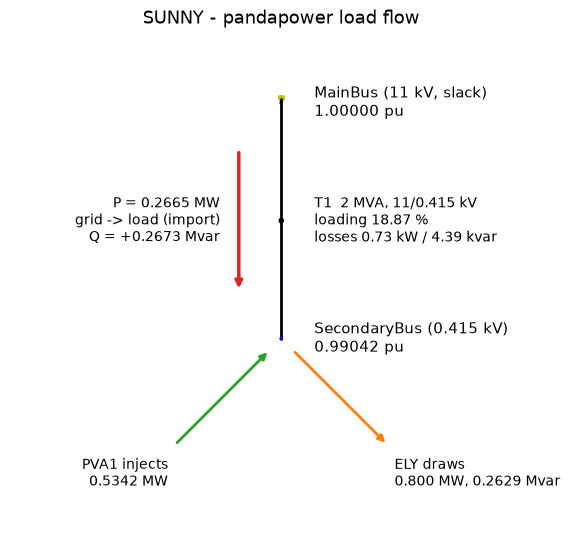

1 in collections is of unknown type. Skipping


saved results\figures\net_night.png

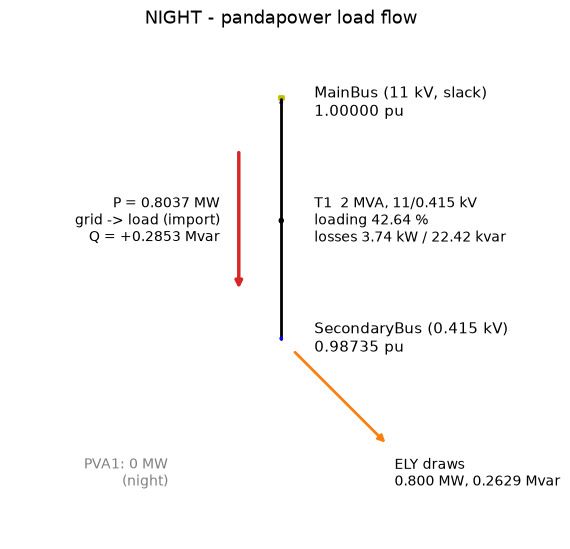

1 in collections is of unknown type. Skipping


saved results\figures\net_pv_export.png

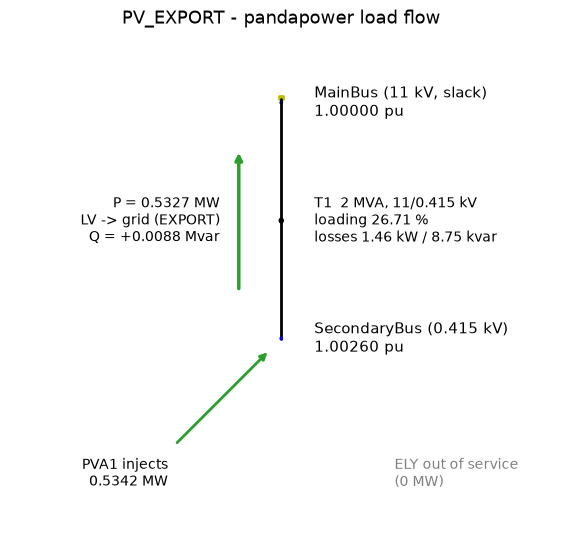

In [4]:
# Annotated single-line diagram per case, drawn with pandapower's built-in
# matplotlib plotting; PNGs go to results/figures/ for the thesis figures.
import contextlib
import io

import matplotlib.pyplot as plt
from pandapower.plotting import simple_plot

GEO = {'MainBus': '{"type": "Point", "coordinates": [0.0, 1.0]}',
       'SecondaryBus': '{"type": "Point", "coordinates": [0.0, 0.0]}'}
fig_dir = repo_root / 'results' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

for case, point in CASES.items():
    net = build_network()
    res = run_case(net, **point)  # solves this case; net keeps its res_* tables
    for bus_name, geojson in GEO.items():
        net.bus.loc[net.bus['name'] == bus_name, 'geo'] = geojson

    fig, ax = plt.subplots(figsize=(7, 7.5))
    with contextlib.redirect_stdout(io.StringIO()):  # hide simple_plot's symbol-skip notice
        simple_plot(net, ax=ax, show_plot=False)

    # Buses with solved voltages
    ax.text(0.14, 1.00, f"MainBus (11 kV, slack)\n{res['v_main_pu']:.5f} pu",
            va='center', fontsize=11)
    ax.text(0.14, 0.00, f"SecondaryBus (0.415 kV)\n{res['v_secondary_pu']:.5f} pu",
            va='center', fontsize=11)

    # Transformer result block
    ax.text(0.14, 0.50,
            f"T1  2 MVA, 11/0.415 kV\nloading {res['trafo_loading_percent']:.2f} %\n"
            f"losses {res['trafo_p_loss_mw'] * 1e3:.2f} kW / {res['trafo_q_loss_mvar'] * 1e3:.2f} kvar",
            va='center', fontsize=10)

    # Grid exchange arrow: red & downward = import, green & upward = export
    p_grid = res['grid_p_mw']
    y_from, y_to = (0.80, 0.20) if p_grid >= 0 else (0.20, 0.80)
    ax.annotate('', xy=(-0.18, y_to), xytext=(-0.18, y_from),
                arrowprops=dict(arrowstyle='-|>', lw=2.5,
                                color='tab:red' if p_grid >= 0 else 'tab:green'))
    direction = 'grid -> load (import)' if p_grid >= 0 else 'LV -> grid (EXPORT)'
    ax.text(-0.26, 0.50, f"P = {abs(p_grid):.4f} MW\n{direction}\nQ = {res['grid_q_mvar']:+.4f} Mvar",
            ha='right', va='center', fontsize=10)

    # ELY draw / PVA1 injection at the secondary bus
    if point['ely_in_service']:
        ax.annotate('', xy=(0.45, -0.45), xytext=(0.05, -0.05),
                    arrowprops=dict(arrowstyle='-|>', lw=2, color='tab:orange'))
        ax.text(0.48, -0.50, f"ELY draws\n{res['ely_p_mw']:.3f} MW, {res['ely_q_mvar']:.4f} Mvar",
                ha='left', va='top', fontsize=10)
    else:
        ax.text(0.48, -0.50, 'ELY out of service\n(0 MW)', ha='left', va='top',
                fontsize=10, color='grey')
    if point['pv_mw'] > 0:
        ax.annotate('', xy=(-0.05, -0.05), xytext=(-0.45, -0.45),
                    arrowprops=dict(arrowstyle='-|>', lw=2, color='tab:green'))
        ax.text(-0.48, -0.50, f"PVA1 injects\n{point['pv_mw']:.4f} MW",
                ha='right', va='top', fontsize=10)
    else:
        ax.text(-0.48, -0.50, 'PVA1: 0 MW\n(night)', ha='right', va='top',
                fontsize=10, color='grey')

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-0.85, 1.30)
    ax.set_title(f'{case} - pandapower load flow', fontsize=13)

    png = fig_dir / f"net_{case.lower()}.png"
    fig.savefig(png, dpi=150, bbox_inches='tight')
    print(f'saved {png.relative_to(repo_root)}')
    plt.show()

## Modeling notes

- **MainBus** is the slack bus, fixed at 1.00000 pu / 0° in both tools by construction; `run_case` returns it as `v_main_pu` but it is not tabulated above.
- **Transformer loading definition:** ETAP reports input-side MVA over rated MVA. `run_case` therefore runs pandapower with `trafo_loading="power"` (max of the two winding MVAs); with no excitation branch the input side always carries the larger apparent power, so the two definitions coincide.
- **ELY reactive power:** the model enters the rated 0.2629 Mvar (800 kW at 0.95 pf lagging); ETAP's result table prints 0.2628 Mvar — a rounding difference far inside the 2 % flow tolerance.
- Section 4's *power through T1 (MVA)* row equals the loading row × 2 MVA / 100, and its *voltage drop* row is implied by the bus voltages, so neither is duplicated here.
- The full comparison is saved to `results/tables/validation_pandapower_vs_etap.csv` for the Chapter 4 validation table.